In [89]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.constraints import max_norm
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [90]:
df = pd.read_csv('PRSA_Data_Changping.csv',sep = ',')
# the dataset has an extra column for the station, remove it
df = df.drop('station', axis=1)
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1


In [91]:
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [92]:
df = df.dropna()

In [93]:
# use results of dtypes to determine categorical and numerical features
catFeatures = ['wd']
df[catFeatures].describe(include='all').loc['unique', :]
unique_labels = len(df['wd'].unique())

# Convert wd categories into numerical values

In [94]:
df['wd'] = df['wd'].astype('category')
df['wd'] = df['wd'].cat.codes
df['wd'].unique()

array([ 0,  1,  5,  3,  6,  7,  4, 12, 11, 15,  2,  9,  8, 14, 10, 13],
      dtype=int8)

In [95]:
X = df.drop('wd', axis=1)
y = df['wd']

#Split the data into training and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 2021)


In [96]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
#Fit and transform the training data
X_train = scaler.fit_transform(X_train)
#Only transform the test data
X_test = scaler.transform(X_test)

In [97]:
input_size = X_train.shape[1]
#specify the number of neuron for the first layer
hidden_size = [20, 10]
print(input_size)

16


# TensorFlow

In [98]:
model = keras.Sequential()
model.add(layers.Dense(input_size, activation='relu'))
model.add(layers.Dense(hidden_size[0], activation='relu'))
model.add(layers.Dense(hidden_size[1], activation='relu'))
# Output layer has a neuron for each unique category
model.add(layers.Dense(units = unique_labels, activation='softmax'))

In [99]:
#Configure the model by choosing optimizer and loss function
model.compile(optimizer='rmsprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [100]:
%%time
#Fix the seed
tf.random.set_seed(1)

# early stop allows me to set the epochs to a high enough value
# for adequate training, and it will stop when results stop improving
# to prevent wasted computations
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#Fit the model and save the results in history
history = model.fit(x=X_train,
                    y=y_train,
                    batch_size=64,
                    epochs=100,
                    validation_data=(X_test,y_test),
                    callbacks=[early_stop],
                    verbose= 1)

print(f"Stopped at epoch: {len(history.history['loss'])}")

Epoch 1/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1291 - loss: 2.6746 - val_accuracy: 0.1602 - val_loss: 2.5972
Epoch 2/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1608 - loss: 2.5667 - val_accuracy: 0.1764 - val_loss: 2.5295
Epoch 3/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1861 - loss: 2.5018 - val_accuracy: 0.1917 - val_loss: 2.4780
Epoch 4/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1934 - loss: 2.4531 - val_accuracy: 0.2001 - val_loss: 2.4380
Epoch 5/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2023 - loss: 2.4139 - val_accuracy: 0.2038 - val_loss: 2.4031
Epoch 6/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2066 - loss: 2.3854 - val_accuracy: 0.2044 - val_loss: 2.3800
Epoch 7/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2097 - loss: 2.3660 - val_accuracy: 0.2044 - val_loss: 2.3618
Epoch 8/100
409/409 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2116 - loss: 2.3516 - val_accu

In [101]:
#Convert the train and validation loss to a df
trainhist = pd.DataFrame(history.history)
#Add the epoch index
trainhist['epoch'] = history.epoch
#Look at the latest performance
trainhist.tail()

,accuracy,loss,val_accuracy,val_loss,epoch
95,0.250459,2.191437,0.232064,2.216725,95
96,0.250497,2.190926,0.231758,2.215688,96
97,0.250497,2.190334,0.232523,2.214899,97
98,0.250459,2.189837,0.232829,2.215710,98
99,0.251186,2.189340,0.231758,2.214975,99


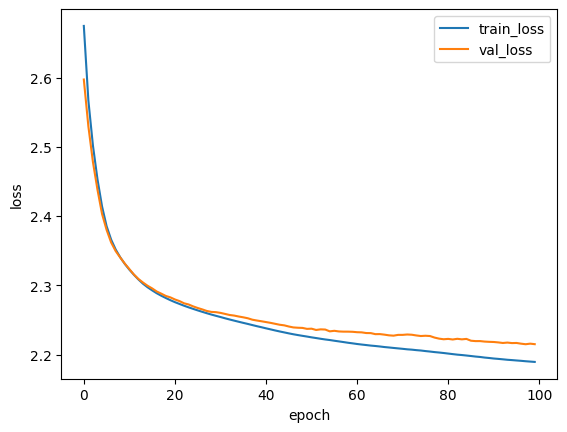

In [102]:
#Plot train loss
sns.lineplot(x='epoch', y ='loss', data =trainhist, label='train_loss')
#Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =trainhist, label='val_loss')
#Add legends
plt.legend()

## Underfitting or Overfitting?
The Tensorflor model is underfitting.  Neither curve has flattened into a horizontal line.  The training loss is still declining.  The validation loss has nearly converged but is slightly declining still.

# Hyperparameter Tuning

In [103]:
import sys
#Import the library of keras-tuner
if ( 'keras-tuner' not in sys.modules):
    #If it was not installed, then install it
    !pip install -q -U keras-tuner
import keras_tuner as kt

In [104]:
def model_builder(hp):
  model = keras.Sequential()

  model.add(layers.Dense(input_size, activation = 'relu'))

  hp_dropout = hp.Float('rate', min_value = 0.2, max_value = 0.8, step = 0.1)

  # first hidden layer with 20 to 100 neurons with a stepsize of 5
  model.add(Dropout(rate = hp_dropout))
  hp_units1 = hp.Int('units_hidden1', min_value = 20, max_value = 100, step = 5)
  model.add(layers.Dense(hp_units1, activation='relu'))

  # second hidden layer with 10 to 50 neurons with a step size of 2
  model.add(Dropout(rate = hp_dropout))
  hp_units2 = hp.Int('units_hidden2', min_value = 10, max_value = 50, step = 2)
  model.add(layers.Dense(hp_units2, activation='relu'))

  # Output layer has a neuron for each unique category
  model.add(layers.Dense(units = unique_labels, activation='softmax'))

  model.compile(optimizer='rmsprop',
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

  return model

In [105]:
tuner = kt.Hyperband(model_builder, #Specify the model
                     objective = 'val_loss', #Specify the objective funciton
                     max_epochs = 100, #Specify the maximum epochs
                     directory = 'my_dir', #Specify the file path
                     project_name = 'tuningRegression')

import IPython
#Clear all the training outputs
class ClearTrainingOutput(tf.keras.callbacks.Callback):
  def on_train_end(*args, **kwargs):
    IPython.display.clear_output(wait = True)

Reloading Tuner from my_dir/tuningRegression/tuner0.json


In [106]:
early_stop_tuner = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,               # keep this small during tuning to save time
    restore_best_weights=True
)
#Perform the search on the defined hyperparameter space by specifying the callback to clear the training outputs
tuner.search(X_train, y_train, epochs = 100, validation_data = (X_test,y_test), callbacks = [ClearTrainingOutput(), early_stop_tuner])

In [107]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials = 1)[0]
#Use f-strings to format the outputs
print(f"""
The optimal number of units in the first hidden layer =  {best_hps.get('units_hidden1')}.
The optimal number of units in the second hidden layer =  {best_hps.get('units_hidden2')}.
The optimal dropout rate in the input layer = {best_hps.get('rate')}
""")


The optimal number of units in the first hidden layer =  40.
The optimal number of units in the second hidden layer =  44.
The optimal droupout rate in the input layer = 0.2



## The optimal number of units in the first hidden layer =  40.
## The optimal number of units in the second hidden layer =  44.
## The optimal dropout rate in the input layer = 0.2



In [108]:
optimal_model = tuner.hypermodel.build(best_hps)

early_stop_optimal = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,                 # stop if no improvement for 10 epochs
    restore_best_weights=True    # revert to best weights when stopped
)
# use a high number of epochs with an early stop
optimal_history = optimal_model.fit(X_train, y_train,
                                    epochs = 100,
                                    validation_data = (X_test,y_test),
                                    callbacks=[early_stop_optimal])

print(f"Stopped at epoch: {len(optimal_history.history['loss'])}")

Epoch 1/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1459 - loss: 2.6185 - val_accuracy: 0.1750 - val_loss: 2.5380
Epoch 2/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1801 - loss: 2.5178 - val_accuracy: 0.2016 - val_loss: 2.4390
Epoch 3/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1950 - loss: 2.4468 - val_accuracy: 0.2093 - val_loss: 2.3803
Epoch 4/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.2010 - loss: 2.4083 - val_accuracy: 0.2142 - val_loss: 2.3535
Epoch 5/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.2041 - loss: 2.3913 - val_accuracy: 0.2146 - val_loss: 2.3384
Epoch 6/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.2059 - loss: 2.3798 - val_accuracy: 0.2137 - val_loss: 2.3255
Epoch 7/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2067 - loss: 2.3708 - val_accuracy: 0.2169 - val_loss: 2.3172
Epoch 8/100
817/817 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2106 - loss: 2.3619 - val_acc

In [109]:
#Convert the train and validation loss to a df
optimal_trainhist = pd.DataFrame(optimal_history.history)
#Add the epoch index
optimal_trainhist['epoch'] = optimal_history.epoch
#Look at the latest performance
optimal_trainhist.tail()

,accuracy,loss,val_accuracy,val_loss,epoch
58,0.229651,2.275102,0.225639,2.261204,58
59,0.228657,2.275670,0.229463,2.264109,59
60,0.232941,2.275225,0.229157,2.259155,60
61,0.228886,2.279066,0.229922,2.261924,61
62,0.227356,2.280142,0.225333,2.271003,62


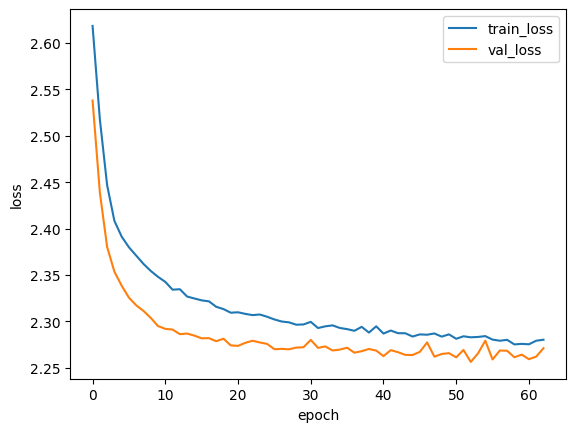

In [110]:
#Plot train loss
sns.lineplot(x='epoch', y ='loss', data =optimal_trainhist, label='train_loss')
#Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =optimal_trainhist, label='val_loss')
#Add legends
plt.legend()

## Underfitting or Overfitting?
The optimal Tensorflow model had 40 layers in the first hidden layer, 44 neurons in the second hidden layer, and a dropout rate of 0.2.  It produces an unusual graph but it looks to be well-fitted, if not *slightly* underfitted or unstable.  I'm giving the answer of well-fitted because the training loss and validation loss are no longer decreasing, they are mostly flat.



# PyTorch

In [111]:
X_train_pytorch = torch.tensor(X_train.astype(np.float32))
y_train_pytorch = torch.tensor(y_train.values.astype(np.int64))#.reshape(-1,1)

input_size = X_train_pytorch.shape[1]
output_size = len(df['wd'].unique())
#specify the number of neuron for the hidden layers
hidden_size = [20, 10]
print(input_size)
print(output_size)

#convert numpy to tensor from_numpy
X_test_pytorch = torch.from_numpy(X_test.astype(np.float32))
y_test_pytorch = torch.tensor(y_test.values.astype(np.int64))

16
16


In [112]:
# define the child module class derivated from parent class of torch.nn.Module)
class LinearClassificationModel(torch.nn.Module):
    #define the constructor
    def __init__(self, input_size,  hidden_size, output_size):
        super(LinearClassificationModel, self).__init__()
        self.hidden1 = torch.nn.Linear(input_size, hidden_size[0])
        self.hidden2 = torch.nn.Linear(hidden_size[0], hidden_size[1])
        self.predict = torch.nn.Linear(hidden_size[1], output_size)
    #overide the forward function in this child class
    def forward(self, x):
        x = F.relu(self.hidden1(x))
        x = F.relu(self.hidden2(x))
        y_pred = self.predict(x)
        return y_pred

In [113]:
model = LinearClassificationModel(input_size, hidden_size,  output_size)
l = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [114]:
%%time

#fix the random seeds for troch and np
torch.manual_seed(1)
np.random.seed(0)


#set the number of epochs
num_epochs = 100000

train_loss = [None]*num_epochs
validation_loss = [None]*num_epochs
for epoch in range(num_epochs):

        output = model(X_train_pytorch)
        loss = l(output, y_train_pytorch)
        train_loss[epoch] = loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #Stop tracking the gradient by calling detach since we don't use it anymore
        y_pred_pytorch = model(X_test_pytorch)#.detach().numpy()
        val_loss = l(y_pred_pytorch, y_test_pytorch)
        validation_loss[epoch] = val_loss.item()
        if epoch % 500 == 0:
            print('epoch {0}, loss = {1:.4f} and val_loss = {2:.4f}'.format(epoch, loss.item(), val_loss))

epoch 0, loss = 2.7684 and val_loss = 2.7707
epoch 500, loss = 2.6782 and val_loss = 2.6749
epoch 1000, loss = 2.6536 and val_loss = 2.6480
epoch 1500, loss = 2.6475 and val_loss = 2.6416
epoch 2000, loss = 2.6446 and val_loss = 2.6386
epoch 2500, loss = 2.6425 and val_loss = 2.6365
epoch 3000, loss = 2.6404 and val_loss = 2.6344
epoch 3500, loss = 2.6382 and val_loss = 2.6323
epoch 4000, loss = 2.6356 and val_loss = 2.6298
epoch 4500, loss = 2.6325 and val_loss = 2.6268
epoch 5000, loss = 2.6288 and val_loss = 2.6233
epoch 5500, loss = 2.6241 and val_loss = 2.6189
epoch 6000, loss = 2.6185 and val_loss = 2.6136
epoch 6500, loss = 2.6119 and val_loss = 2.6074
epoch 7000, loss = 2.6050 and val_loss = 2.6009
epoch 7500, loss = 2.5981 and val_loss = 2.5944
epoch 8000, loss = 2.5909 and val_loss = 2.5879
epoch 8500, loss = 2.5836 and val_loss = 2.5812
epoch 9000, loss = 2.5763 and val_loss = 2.5746
epoch 9500, loss = 2.5691 and val_loss = 2.5682
epoch 10000, loss = 2.5623 and val_loss = 2.

In [115]:
#Convert the train and validation loss to a df
trainhist = pd.DataFrame({'train_loss': train_loss, 'val_loss': validation_loss, 'epoch':np.arange(num_epochs)})
#Look at the latest performance
trainhist.tail()

,train_loss,val_loss,epoch
99995,2.277715,2.287031,99995
99996,2.277714,2.287030,99996
99997,2.277713,2.287029,99997
99998,2.277713,2.287029,99998
99999,2.277712,2.287028,99999


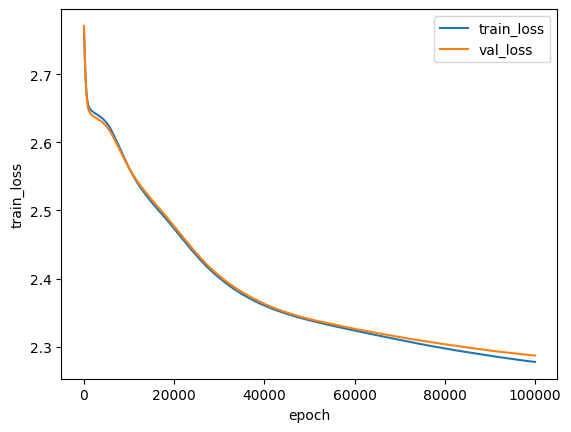

In [116]:
import matplotlib.pyplot as plt
#Plot train loss
sns.lineplot(x='epoch', y ='train_loss', data =trainhist, label='train_loss')
#Plot validation loss
sns.lineplot(x='epoch', y ='val_loss', data =trainhist, label='val_loss')
#Add legends
plt.legend()

## Underfitting or Overfitting?
The PyTorch model is underfit.  Both the validation loss and and training loss are still decreasing slightly.  Even with 100k epochs the results have not converged.

I suspect the limiting factor is the number of neurons in the network.  The second layer only has 10 neurons and the output layer has 16.  I think the second layer having fewer neurons than the output layer is limiting the model's ability to learn.